In [36]:

''' Set up for Jupyter Notebook to automatically reload modules before executing code - easier debugging and development '''
%load_ext autoreload
%autoreload 2

''' General Imports '''
from RBS_network_models.utils.netpyne_helpers import *
from pprint import pprint

''' Model Imports '''
from RBS_network_models.models.CDKL5_E6D_T2_C1_05212024.DIV21_WT.src.evol_params import params
from RBS_network_models.models.CDKL5_E6D_T2_C1_05212024.DIV21_WT.src.conv_params import conv_params, mega_params

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
''' Specify Paths of Interest '''
#SIM_DATA_PATH = "/global/homes/a/adammwea/pscratch/z_simulated_data/CDKL5-E6D_T2_C1_05212024/DIV21_WT/sensitivity_analysis/batch_2025-05-28_spiking_only/gen_0/gen_0_cand_32/tau2_exc_3/tau2_exc_3_data.pkl"
SIM_DATA_PATH = '/global/homes/a/adammwea/pscratch/z_simulated_data/CDKL5-E6D_T2_C1_05212024/DIV21_WT/manual_tunning/batch_2025-05-28_spiking_only/gen_0_cand_32_tau2_exc_3/pIE_0.075_pEE_0.15_lambda_900/pIE_0.075_pEE_0.15_lambda_900_data.pkl'
SIM_METRICS_PATH = '/global/homes/a/adammwea/pscratch/z_simulated_data/CDKL5-E6D_T2_C1_05212024/DIV21_WT/sensitivity_analysis/batch_2025-05-28_spiking_only/gen_0_cand_32_tau2_exc_3/_tau2_exc_3/_tau2_exc_3/network_data.npy'
REFERENCE_DATA = '/global/homes/a/adammwea/pscratch/z_analyzed_data/CDKL5-E6D_T2_C1_05212024/CDKL5-E6D_T2_C1_05212024/240611/M08029/Network/000091/network_analysis/well005/metrics.npy'
#SAVE_FOLDER = '/global/homes/a/adammwea/pscratch/z_simulated_data/CDKL5-E6D_T2_C1_05212024/DIV21_WT/manual_tunning/batch_2025-05-28_spiking_only/gen_0_cand_32_tau2_exc_3/'
SAVE_FOLDER = '/global/homes/a/adammwea/pscratch/z_simulated_data/CDKL5-E6D_T2_C1_05212024/DIV21_WT/manual_tunning/27jun2025_CDKL5_DIV21_WT/nb2'
SIM_CFG_PATH = derive_sim_cfg_path_from_sim_data_path(SIM_DATA_PATH)


EVOL_PARAMS = params # params used for evolutionary bounds in optimization and sensitivity analysis. Useful to warn user if modifcations break these bounds.
CONV_PARAMS = conv_params
MEGA_PARAMS = mega_params  # params used for evolutionary bounds in optimization and sensitivity analysis. Useful to warn user if modifcations break these bounds.

''' Set up Simulation Configuration '''
# print
print(f"Simulation Data Path: {SIM_DATA_PATH}")
print(f"Reference Data Path: {REFERENCE_DATA}")
print(f"Simulation Config Path: {SIM_CFG_PATH}")

Simulation Data Path: /global/homes/a/adammwea/pscratch/z_simulated_data/CDKL5-E6D_T2_C1_05212024/DIV21_WT/manual_tunning/batch_2025-05-28_spiking_only/gen_0_cand_32_tau2_exc_3/pIE_0.075_pEE_0.15_lambda_900/pIE_0.075_pEE_0.15_lambda_900_data.pkl
Reference Data Path: /global/homes/a/adammwea/pscratch/z_analyzed_data/CDKL5-E6D_T2_C1_05212024/CDKL5-E6D_T2_C1_05212024/240611/M08029/Network/000091/network_analysis/well005/metrics.npy
Simulation Config Path: /global/homes/a/adammwea/pscratch/z_simulated_data/CDKL5-E6D_T2_C1_05212024/DIV21_WT/manual_tunning/batch_2025-05-28_spiking_only/gen_0_cand_32_tau2_exc_3/pIE_0.075_pEE_0.15_lambda_900/pIE_0.075_pEE_0.15_lambda_900_cfg.json


In [38]:
''' Load and Plot 'Before' Simulation Data '''
from IPython.display import Image, display
from netpyne import sim, specs
#SIM_RASTER_PNG_PATH = SIM_DATA_PATH.replace('.pkl', '_raster.png')
sim_dir = os.path.dirname(SIM_METRICS_PATH)
# search sim_dir for files ending in _2p.png
SIM_RASTER_PNG_PATH = glob.glob(os.path.join(sim_dir, '*_2p.png'))
if SIM_RASTER_PNG_PATH:
    SIM_RASTER_PNG_PATH = SIM_RASTER_PNG_PATH[0]
else:
    SIM_RASTER_PNG_PATH = None
    
# show raster plot if it exists
if SIM_RASTER_PNG_PATH:
    print(f"Raster Plot Path: {SIM_RASTER_PNG_PATH}")
    # show the raster plot
    display(Image(filename=SIM_RASTER_PNG_PATH))

Raster Plot Path: /global/homes/a/adammwea/pscratch/z_simulated_data/CDKL5-E6D_T2_C1_05212024/DIV21_WT/sensitivity_analysis/batch_2025-05-28_spiking_only/gen_0_cand_32_tau2_exc_3/_tau2_exc_3/_tau2_exc_3/network_summary_2p.png


In [39]:
''' Load Simulation cfg and netParams'''
from netpyne import sim, specs
#sim_cfg = load_sim_config_from_json(SIM_CFG_PATH)
sim_cfg = get_cfg_obj_from_sim_pkl(SIM_DATA_PATH)
net_params = get_netParam_obj_from_sim_pkl_path(SIM_DATA_PATH)

''' Print Simulation cfg and netParams '''
print("Simulation Config:")
pprint(sim_cfg.__dict__)
print("Network Parameters:")
pprint(net_params.__dict__)


/global/u2/a/adammwea/dev/RBS_network_models/RBS_network_models/utils/netpyne_helpers.py:825: UserWarning: This method requires the netpyne sim module to be cleared before loading. If you had previously loaded a simulation, it will be cleared now.
  warnings.warn("This method requires the netpyne sim module to be cleared before loading. "



Start time:  2025-06-27 22:35:16.920613
Loading file /global/homes/a/adammwea/pscratch/z_simulated_data/CDKL5-E6D_T2_C1_05212024/DIV21_WT/manual_tunning/batch_2025-05-28_spiking_only/gen_0_cand_32_tau2_exc_3/pIE_0.075_pEE_0.15_lambda_900/pIE_0.075_pEE_0.15_lambda_900_data.pkl ... 
  Done; file loading time = 0.74 s
Loading simConfig...
Loading netParams...
Loading net...
  Created 301 cells
  Created 2262 connections
  Created 0 stims
  Added NEURON objects to 301 cells
  Done; re-instantiate net time = 0.43 s
Loading simData...
Recording 0 traces of 0 types on node 0
Loading file /global/homes/a/adammwea/pscratch/z_simulated_data/CDKL5-E6D_T2_C1_05212024/DIV21_WT/manual_tunning/batch_2025-05-28_spiking_only/gen_0_cand_32_tau2_exc_3/pIE_0.075_pEE_0.15_lambda_900/pIE_0.075_pEE_0.15_lambda_900_data.pkl ... 
  Done; file loading time = 0.65 s
Loading netParams...
Simulation Config:
{'E_L_mean': 706.545496982365,
 'E_L_stdev': 2.2966779585432895,
 'E_Ra_mean': 70.66628031104251,
 'E_Ra_st

In [40]:


''' Modify Simulation cfg and netParams as needed 
        options:
        - set_value: Set a parameter to a specific value.
        - mult_value: Multiply the current value of a parameter by a specified factor.
        - add_value: Add a specified value to the current value of a parameter.
        - evol_params: A dictionary of evolutionary parameters to check against.
        - verbose: If True, print detailed changes made to the parameters.
'''
#
# simLabel = 'pIE_0.075_pEE_0.15_lambda_900'
# mutate_sim_and_net_params(net_params, sim_cfg, 'probIE', set_value=0.075,
#                           evol_params=EVOL_PARAMS, verbose=True)
# mutate_sim_and_net_params(net_params, sim_cfg, 'probEE', set_value=0.15,
#                           evol_params=EVOL_PARAMS, verbose=True)
# mutate_sim_and_net_params(net_params, sim_cfg, 'probLengthConst', set_value=900,
#                           evol_params=EVOL_PARAMS, verbose=True)

#
# simLabel = 'tau2_inh_1.0'
# mutate_sim_and_net_params(net_params, sim_cfg, 'tau2_inh', set_value=1.0,
#                           evol_params=EVOL_PARAMS, verbose=True)

#
simLabel = 'tau2_inh_1.0_pIE_0.01'
mutate_sim_and_net_params(net_params, sim_cfg, 'tau2_inh', set_value=1.0,
                          evol_params=EVOL_PARAMS, verbose=True)
mutate_sim_and_net_params(net_params, sim_cfg, 'probIE', set_value=0.01,
                          evol_params=EVOL_PARAMS, verbose=True)
                          

''' Set up simLabel and save folder in simulation configuration '''
# derive simulation label from SIM_DATA_PATH
saveFolder = os.path.join(SAVE_FOLDER, simLabel)

# set attributes for simulation configuration
set_attr_sim_cfg(sim_cfg, 'saveFolder', saveFolder)
set_attr_sim_cfg(sim_cfg, 'simLabel', simLabel)

''' Set duration very low for testing purposes '''
# set duration very low for testing purposes
#set_attr_sim_cfg(sim_cfg, 'duration', 1000)  # set duration to 1000 ms for testing

print(f"Simulation Label: {sim_cfg.simLabel}")
print(f"Simulation Save Folder: {sim_cfg.saveFolder}")
print(f"Simulation Duration: {sim_cfg.duration} ms")

Mutating parameter 'tau2_inh' in both netParams and simConfig...
	Set 'tau2_inh' to 1.0 at path 'synMechParams.inh.tau2'.
	Mutated parameter 'tau2_inh': 595.5309136077385 -> 1.0
Mutating parameter 'probIE' in both netParams and simConfig...
	Set 'probIE' to 0.01 at path 'connParams.I->E.probability'.
	Mutated parameter 'probIE': 0.075 -> 0.01
Simulation Label: tau2_inh_1.0_pIE_0.01
Simulation Save Folder: /global/homes/a/adammwea/pscratch/z_simulated_data/CDKL5-E6D_T2_C1_05212024/DIV21_WT/manual_tunning/27jun2025_CDKL5_DIV21_WT/nb2/tau2_inh_1.0_pIE_0.01
Simulation Duration: 140000.0 ms


In [41]:
''' Clear previous simulation data and mappings '''
# remove previous data (if any)
try: sim.clearAll()
except: pass

#remove mapping from netParams #TODO: figure out how to actually take advantage of this
net_params.mapping = {}

# Create network
sim.initialize(                     # create network object and set cfg and net params
        simConfig = sim_cfg,          # pass simulation config and network params as arguments
        netParams = net_params)
sim.net.createPops()                # instantiate network populations
sim.net.createCells()               # instantiate network cells based on defined populations
sim.net.connectCells()              # create connections between cells based on params
sim.net.addStims()                  # add stimulation (usually there are none)
sim.setupRecording()                # setup variables to record for each cell (spikes, V traces, etc)

''' Run Simulation - standard procedure '''
# run simulation
sim.runSim()
sim.gatherData()                # gather recorded data from cells

# save simulation data
output_paths = sim.saveData()  # save data to file
output_path = output_paths[0] if output_paths else None
print(f"Simulation data saved to: {output_path}")


Start time:  2025-06-27 22:35:19.464191
Validating NetParams ...
  Successfully validated generalParams
  Successfully validated cellParams
  Successfully validated popParams
  Successfully validated synMechParams
  Successfully validated connParams
  Successfully validated subConnParams
  Successfully validated stimSourceParams
  Successfully validated stimTargetParams

NetParams validation successful.





Creating network of 2 cell populations on 1 hosts...: 100%|##########|


  Number of cells on node 0: 301 
  Done; cell creation time = 0.44 s.
Making connections...


  E->I: 100%|##########| Creating synaptic connections for 98/98 postsynaptic cells on node 0 (probabilistic connectivity)
  I->E: 100%|##########| Creating synaptic connections for 203/203 postsynaptic cells on node 0 (probabilistic connectivity)
  E->E: 100%|##########| Creating synaptic connections for 203/203 postsynaptic cells on node 0 (probabilistic connectivity)
  I->I: 100%|##########| Creating synaptic connections for 98/98 postsynaptic cells on node 0 (probabilistic connectivity)


  Number of connections on node 0: 1986 
  Done; cell connection time = 0.72 s.
  Number of stims on node 0: 0 
  Done; cell stims creation time = 0.00 s.
Recording 0 traces of 0 types on node 0

Running simulation using NEURON for 140000.0 ms...
  Done; run time = 301.44 s; real-time ratio: 0.46.

Gathering data...
  Done; gather time = 0.11 s.

Analyzing...
  Cells: 301
  Connections: 1986 (6.60 per cell)
  Spikes: 187795 (4.46 Hz)
  Simulated time: 140.0 s; 1 workers
  Run time: 301.44 s
   E : 1.517 Hz
   I : 10.555 Hz
Saving output as /global/homes/a/adammwea/pscratch/z_simulated_data/CDKL5-E6D_T2_C1_05212024/DIV21_WT/manual_tunning/27jun2025_CDKL5_DIV21_WT/nb2/tau2_inh_1.0_pIE_0.01/tau2_inh_1.0_pIE_0.01_data.pkl ... 
Finished saving!
  Done; saving time = 0.71 s.
Simulation data saved to: /global/homes/a/adammwea/pscratch/z_simulated_data/CDKL5-E6D_T2_C1_05212024/DIV21_WT/manual_tunning/27jun2025_CDKL5_DIV21_WT/nb2/tau2_inh_1.0_pIE_0.01/tau2_inh_1.0_pIE_0.01_data.pkl


In [42]:
''' Compute Network Metrics and Plot Results '''
from MEA_Analysis.NetworkAnalysis.awNetworkAnalysis.network_analysis import compute_network_metrics
from copy import deepcopy
from MEA_Analysis.NetworkAnalysis.awNetworkAnalysis.network_analysis import plot_network_metrics_v2

''' sim '''
#sim.load(SAVE_FOLDER)  # load the simulation data from the saved path

''' Prepare Network Metrics Computation '''
kwargs = {
    'simData': deepcopy(sim.allSimData.todict()),
    'popData': sim.net.allPops.copy(),
    'cellData': sim.net.allCells.copy(),
    'run_parallel': True,
    'debug_mode': False,
    'max_workers': 24, # dont do more than 24 in login node,
    'sim_data_path': output_path,
    'burst_sequencing': True,
    'dtw_matrix': False,
    'conv_params': CONV_PARAMS,
    'mega_params': MEGA_PARAMS,
    'source': 'simulated',
}

new_sim_dir = os.path.dirname(output_path)
network_data_path = os.path.join(new_sim_dir, 'network_data.npy')
# if network_data_path exists, load it
if os.path.exists(network_data_path):
    print(f"Network data already exists at: {network_data_path}")
    network_data = np.load(network_data_path, allow_pickle=True).item()
    network_data['sim_data_path'] = output_path  # update sim_data_path in network_data
    print("Loaded existing network data.")
else:
    print(f"Network data not found at: {network_data_path}, computing new metrics...")

    ''' Compute Network Metrics '''
    network_data = compute_network_metrics(**kwargs)
    network_data['sim_data_path'] = output_path
    np.save(network_data_path, network_data)
    print(f"Network data saved to: {network_data_path}")

''' Plot Network Metrics '''
pkwargs = {'y_lim':tuple([0,16]),}
parallel = False # there's only one simulation, so no need to parallelize
num_workers = 24
npy_list = [network_data]
plot_network_metrics_v2(npy_list, pkwargs, parallel=parallel, num_workers=num_workers)
print("Network metrics plotted successfully.")

''' Load and Show Raster Plot '''
new_sim_raster_png_path = glob.glob(os.path.join(new_sim_dir, simLabel, '*_2p.png'))
if new_sim_raster_png_path:
    new_sim_raster_png_path = new_sim_raster_png_path[0]
else:
    new_sim_raster_png_path = None
if new_sim_raster_png_path:
    print(f"New Raster Plot Path: {new_sim_raster_png_path}")
    # show the raster plot
    display(Image(filename=new_sim_raster_png_path))





Network data not found at: /global/homes/a/adammwea/pscratch/z_simulated_data/CDKL5-E6D_T2_C1_05212024/DIV21_WT/manual_tunning/27jun2025_CDKL5_DIV21_WT/nb2/tau2_inh_1.0_pIE_0.01/network_data.npy, computing new metrics...
⚡ Computing spiking metrics by unit...
🚀 Running in parallel with 24 workers...
Processing unit 0...
Processing unit 1...
Processing unit 2...
Processing unit 3...
Processing unit 4...
Processing unit 5...
Processing unit 6...
Processing unit 7...
Processing unit 8...
Processing unit 9...
Processing unit 10...
Processing unit 11...
Processing unit 12...
Processing unit 13...
Processing unit 14...
Processing unit 15...
Processing unit 16...
Processing unit 17...
Processing unit 18...
Processing unit 19...
Processing unit 20...
Processing unit 21...
Processing unit 22...
Processing unit 23...
Processing unit 24...
Processing unit 25...
Processing unit 26...
Processing unit 27...
Processing unit 28...
Processing unit 29...
Processing unit 30...
Processing unit 31...
Proce

Raster plots are available for display.
Raster plots saved to: /global/homes/a/adammwea/pscratch/z_simulated_data/CDKL5-E6D_T2_C1_05212024/DIV21_WT/manual_tunning/27jun2025_CDKL5_DIV21_WT/nb2/tau2_inh_1.0_pIE_0.01/raster_plots_comparison.png


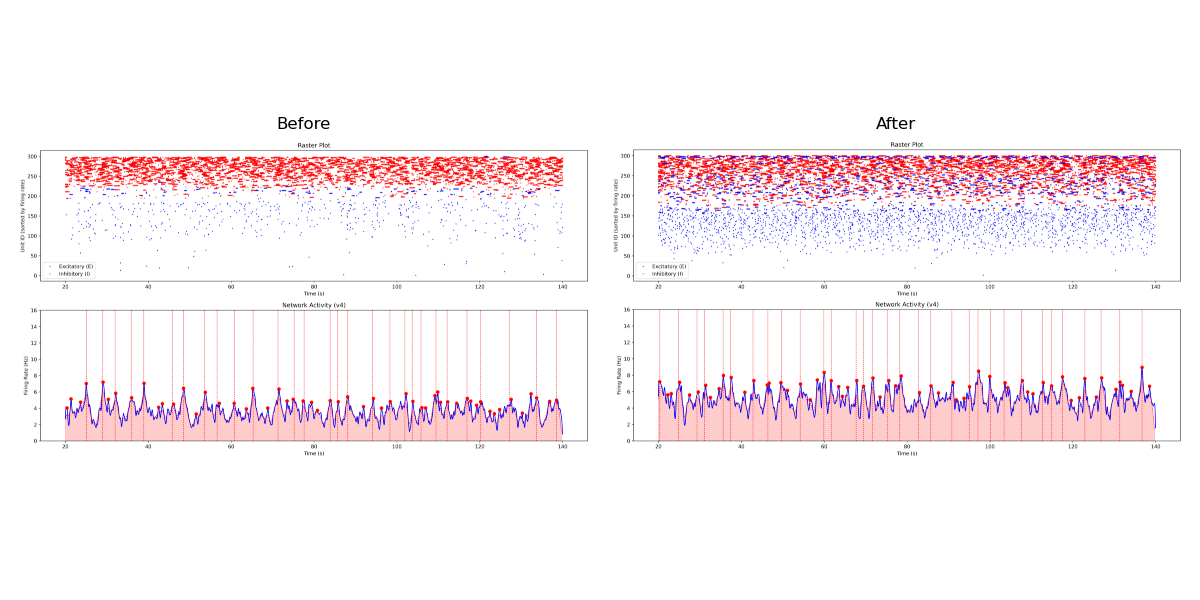

In [43]:
''' Show before and after pngs side by side '''
from IPython.display import display, Image
from matplotlib import pyplot as plt
# Display the before and after raster plots side by side
if SIM_RASTER_PNG_PATH and new_sim_raster_png_path:
    # display(Image(filename=SIM_RASTER_PNG_PATH, width=400, height=300))
    # display(Image(filename=new_sim_raster_png_path, width=400, height=300))
    # make one image with both raster plots side by side
    print("Raster plots are available for display.")
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(plt.imread(SIM_RASTER_PNG_PATH))
    ax[0].set_title('Before')
    ax[0].axis('off')  # Hide axes for the first plot
    ax[1].imshow(plt.imread(new_sim_raster_png_path))
    ax[1].set_title('After')
    ax[1].axis('off')  # Hide axes for the second plot
    plt.tight_layout()
    #plt.show()
    plt.savefig(os.path.join(new_sim_dir, 'raster_plots_comparison.png'))
    print(f"Raster plots saved to: {os.path.join(new_sim_dir, 'raster_plots_comparison.png')}")
    plt.close(fig)  # Close the figure to free up memory
    #display(fig)  # Display the figure in the notebook
    display(Image(filename=os.path.join(new_sim_dir, 'raster_plots_comparison.png')))
else:
    print("One or both raster plots are not available for display.")    